$f(x) = \frac{1}{2} x^T A x + b \cdot x$ \
$g(x) \leq 0$ \
$g(x) = \|x - x_0\| - r$ \
$A \in \mathbb{R}^{4 \times 4}$ — невырожденная симметричная **неопределённая** матрица (имеет собственные значения разных знаков) \
$b, x_0 \in \mathbb{R}^4$ \
$r > 0$ \
$\mathcal{X} = \{ x : \|x - x_0\| \leq r \}$.

### Метод касательных
На каждой итерации:
1. Вычисляем антиградиент $d_k = -\nabla f(x_k) = -(Ax_k + b)$
2. Проецируем направление на касательную плоскость $y=x-\alpha \nabla f(x_k)$
3. Смещаем результат обратно в допустимую зону(шар) $x_{new} = \text{proj}_{\mathcal{X}}(y) = x_0 + r \cdot \frac{y - x_0}{\max(\|y - x_0\|,\, r)}$ \
    (через max одновременно учитываем случаи выхода за границу и нахождение внутри)


In [158]:
from typing import Literal
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import minimize, NonlinearConstraint

np.random.seed(42)
TOL = np.float64(1e-12)

In [159]:
@dataclass
class Data:
    A: np.ndarray
    b: np.ndarray
    x0: np.ndarray
    r: np.floating
    

In [160]:
def f(data: Data, x: np.ndarray):
    return 0.5 * x @ data.A @ x + data.b @ x

def f_grad(data: Data, x: np.ndarray):
    return data.A @ x + data.b

def g(data: Data, x: np.ndarray):
    return np.linalg.norm(x - data.x0) - data.r

def project_ball(data: Data, y: np.ndarray):
    t = max(np.linalg.norm(y - data.x0), data.r)
    return data.x0 + data.r * (y - data.x0) / t

In [161]:
def demonstrate(history: dict[str, list], f_ideal: float):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    iters = np.arange(1, len(history['f']) + 1)

    # --- f(x_k) ---
    axes[0].plot(iters, history['f'], color='steelblue', lw=2)
    axes[0].axhline(f_ideal, color='tomato', ls='--', lw=1.5, label=f'f(x*) = {f_ideal:.4f}')
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title('Убывание целевой функции')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- ||grad f(x_k)|| ---
    axes[1].semilogy(iters, history['grad_norm'], color='darkorange', lw=2)
    axes[1].set_xlabel('Итерация')
    axes[1].set_ylabel(r'$\|\nabla f(x_k)\|$  (log scale)')
    axes[1].set_title('Норма градиента')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [162]:
def projected_gradient(
    data: Data,
    x_start: np.ndarray | None = None,
    max_iter: int = 5_000,
    tol: np.floating = TOL,
    alpha: np.floating = np.float64(0.01),
):
    if x_start is not None:
        x = project_ball(data, x_start)
    else:
        x = data.x0
    history: dict[str, list] = {
        'f': [f(data, x)],
        'grad_norm': [np.linalg.norm(f_grad(data, x))],
        'x': [x.copy()]
    }

    for k in range(max_iter):
        x_new = project_ball(data, y=(x-alpha*f_grad(data, x)))

        history['f'].append(f(data, x_new))
        history['grad_norm'].append(np.linalg.norm(f_grad(data, x_new)))
        history['x'].append(x_new.copy())

        step_norm = np.linalg.norm(x_new - x)
        # if f(data, x_new) > f(data, x):
        #     print(f"новый x больше старого x на итерации {k+1}, что не должно происходить для метода градиентного спуска.")
        #     break
        if g(data, x_new) > tol:
            print(f"новый x не удовлетворяет ограничению на итерации {k+1}.")
            break
        x = x_new
        if step_norm < tol:
            print(f"Сходимость достигнута на итерации {k+1}")
            break
    else:
        print("Достигнут лимит итераций.")

    return x, history

In [163]:
def get_ideal_result(
    data: Data,
    max_iter: int = 5_000,
    tol: np.floating = TOL,
):
    constraint = NonlinearConstraint(
        fun=lambda x: np.linalg.norm(x - data.x0),
        lb=-np.inf,
        ub=data.r
    )

    res = minimize(
        fun=lambda x: f(data, x),
        x0=data.x0,
        jac=lambda x: f_grad(data, x),
        method='SLSQP',
        constraints=constraint,
        options={'ftol': tol, 'maxiter': max_iter}
    )
    return res.x, res.fun

In [164]:
A = [
 [-0.6333, -0.6542, 1.2504,  -1.2375],
 [-0.6542, 3.1035,  0.2128,  -0.32  ],
 [ 1.2504, 0.2128,  -1.4615, -0.6738],
 [-1.2375, -0.32,   -0.6738, -0.698 ],
]
b  = [1.0, -2.0, 0.5, 3.0]
x0 = [1.0, 1.0, 1.0, 1.0]
r  = 2.0
test_data = Data(A=np.array(A), b=np.array(b), x0=np.array(x0), r=np.float64(r))


x_opt, history = projected_gradient(test_data)
f_opt = f(test_data, x_opt)
x_ideal, f_ideal = get_ideal_result(test_data)


print(f"результат: {f_opt:.8f}, другой результат: {f_ideal:.8f}")
print(f"точность: {(f_opt - f_ideal):.4e}")
if f_opt < f_ideal:
    print("достигли эталона")
print(x_opt)

Сходимость достигнута на итерации 3466
результат: -3.75540334, другой результат: -3.75540334
точность: 3.7126e-12
[ 2.42681394  1.18382687 -0.29856005  1.49411685]


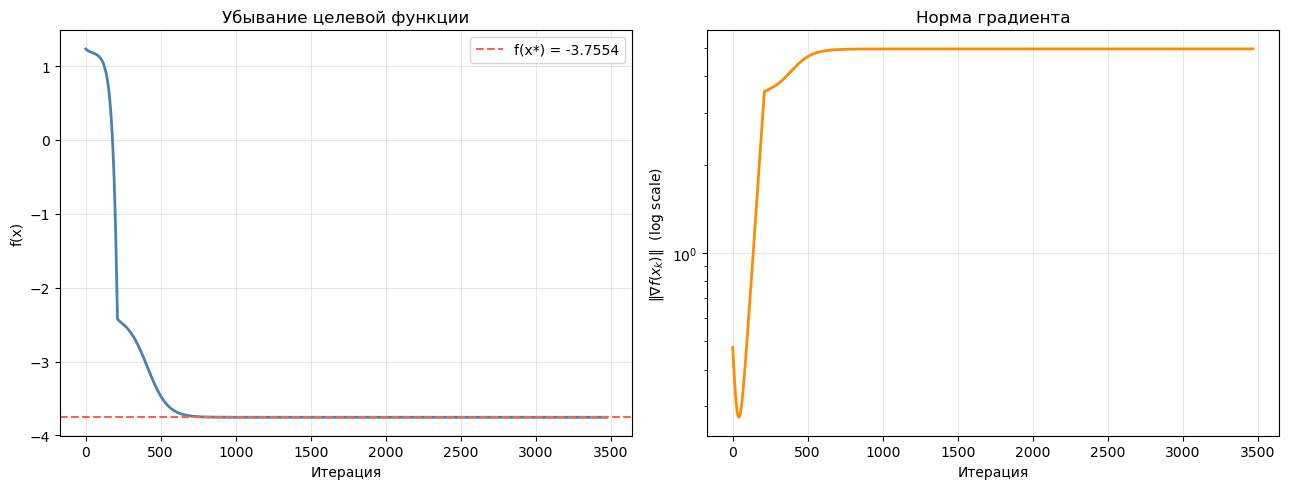

In [165]:
demonstrate(history, f_ideal)

In [166]:
def generate_random_float_value(min_val=-10, max_val=10):
    return np.random.random() * (max_val - min_val) + min_val

def generate_random_value(min_val=-10, max_val=10):
    return np.random.randint(min_val, max_val)

def generate_matrix(n=4, m=1, min_val=-10, max_val=10):
    return np.random.uniform(min_val, max_val, (n, m)).astype(np.float64)

def generate_symmetric_matrix(n=4, min_val=-10, max_val=10):
    random_matrix = generate_matrix(n, n)
    symmetric_matrix = (random_matrix + random_matrix.T) / 2
    return symmetric_matrix

def generate_symmetric_indefinite_nondegenerate_matrix(n=4, min_val=-10, max_val=10):
    for i in range(100_000):
        A = generate_symmetric_matrix(n, min_val, max_val)
        det = np.linalg.det(A)
        if abs(det) < 1e-10:
            continue
        eigs, _ = np.linalg.eig(A)
        if not any(eigs > 0) or not any(eigs < 0):
            continue
        return A
    else:
        raise ValueError("Не удалось сгенерировать невырожденную симметричную неопределённую матрицу")

def generate_test_data():
    A = generate_symmetric_indefinite_nondegenerate_matrix()
    b = generate_matrix().flatten()
    x0 = generate_matrix().flatten()
    r = generate_random_value(0, 5)
    return Data(A=A, b=b, x0=x0, r=r)


def generate_x_start(x0, r, position: Literal["inside", "border", "outside"]):
    random_vector = generate_matrix().flatten()
    random_vector_one = random_vector / np.linalg.norm(random_vector)
    our_r = None
    match position:
        case "inside":
            our_r = generate_random_float_value(0.001, r)
        case "border":
            our_r = r
        case "outside":
            our_r = generate_random_float_value(r+0.001, 2*r)

    return x0 + our_r * random_vector_one
            


In [167]:
test_data = generate_test_data()
print("A=")
pprint(test_data.A)
print()
print("b=")
pprint(test_data.b)
print()
print("x0=")
pprint(test_data.x0)
print()
print("r=")
pprint(test_data.r)

A=
array([[-2.50919762,  1.06732947,  3.33108954,  4.31101125],
       [ 1.06732947, -6.88010959, -2.3384381 ,  0.78515256],
       [ 3.33108954, -2.3384381 , -9.58831011,  1.51734819],
       [ 4.31101125,  0.78515256,  1.51734819, -6.3319098 ]])

b=
array([-3.91515514,  0.49512863, -1.36109963, -4.1754172 ])

x0=
array([ 2.23705789, -7.21012279, -4.15710703, -2.67276313])

r=
2


In [175]:
x_start = generate_x_start(test_data.x0, test_data.r, position="border")
x_start, g(test_data, x_start)

(array([ 1.142132  , -6.43529767, -3.69204899, -1.26403876]),
 np.float64(-2.220446049250313e-16))

In [176]:
x_opt, history = projected_gradient(test_data, x_start=x_start)
f_opt = f(test_data, x_opt)
x_ideal, f_ideal = get_ideal_result(test_data)


print(f"результат: {f_opt:.8f}, другой результат: {f_ideal:.8f}")
print(f"точность: {(f_opt - f_ideal):.4e}")
if f_opt < f_ideal:
    print("достигли эталона")
print(x_opt)

Сходимость достигнута на итерации 77
результат: -610.82614497, другой результат: -610.82614503
точность: 5.4446e-08
[ 3.10773646 -8.43721726 -5.45731817 -2.88632576]


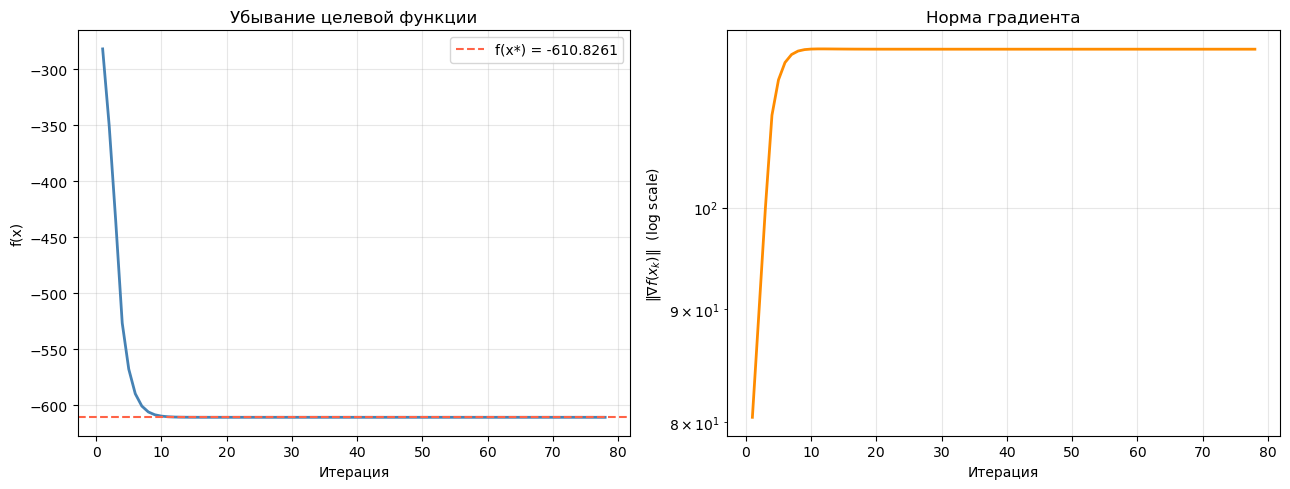

In [177]:
demonstrate(history, f_ideal)